<a href="https://colab.research.google.com/github/tharindidinuja-lang/customer-churn-analysis/blob/main/task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

libraries imported successfully

 Telco_Customer_Churn_Dataset .csv


Saving Telco_Customer_Churn_Dataset .csv to Telco_Customer_Churn_Dataset .csv

 data loaded: 7043 rows, 21 columns
overall churn rate: 26.58%


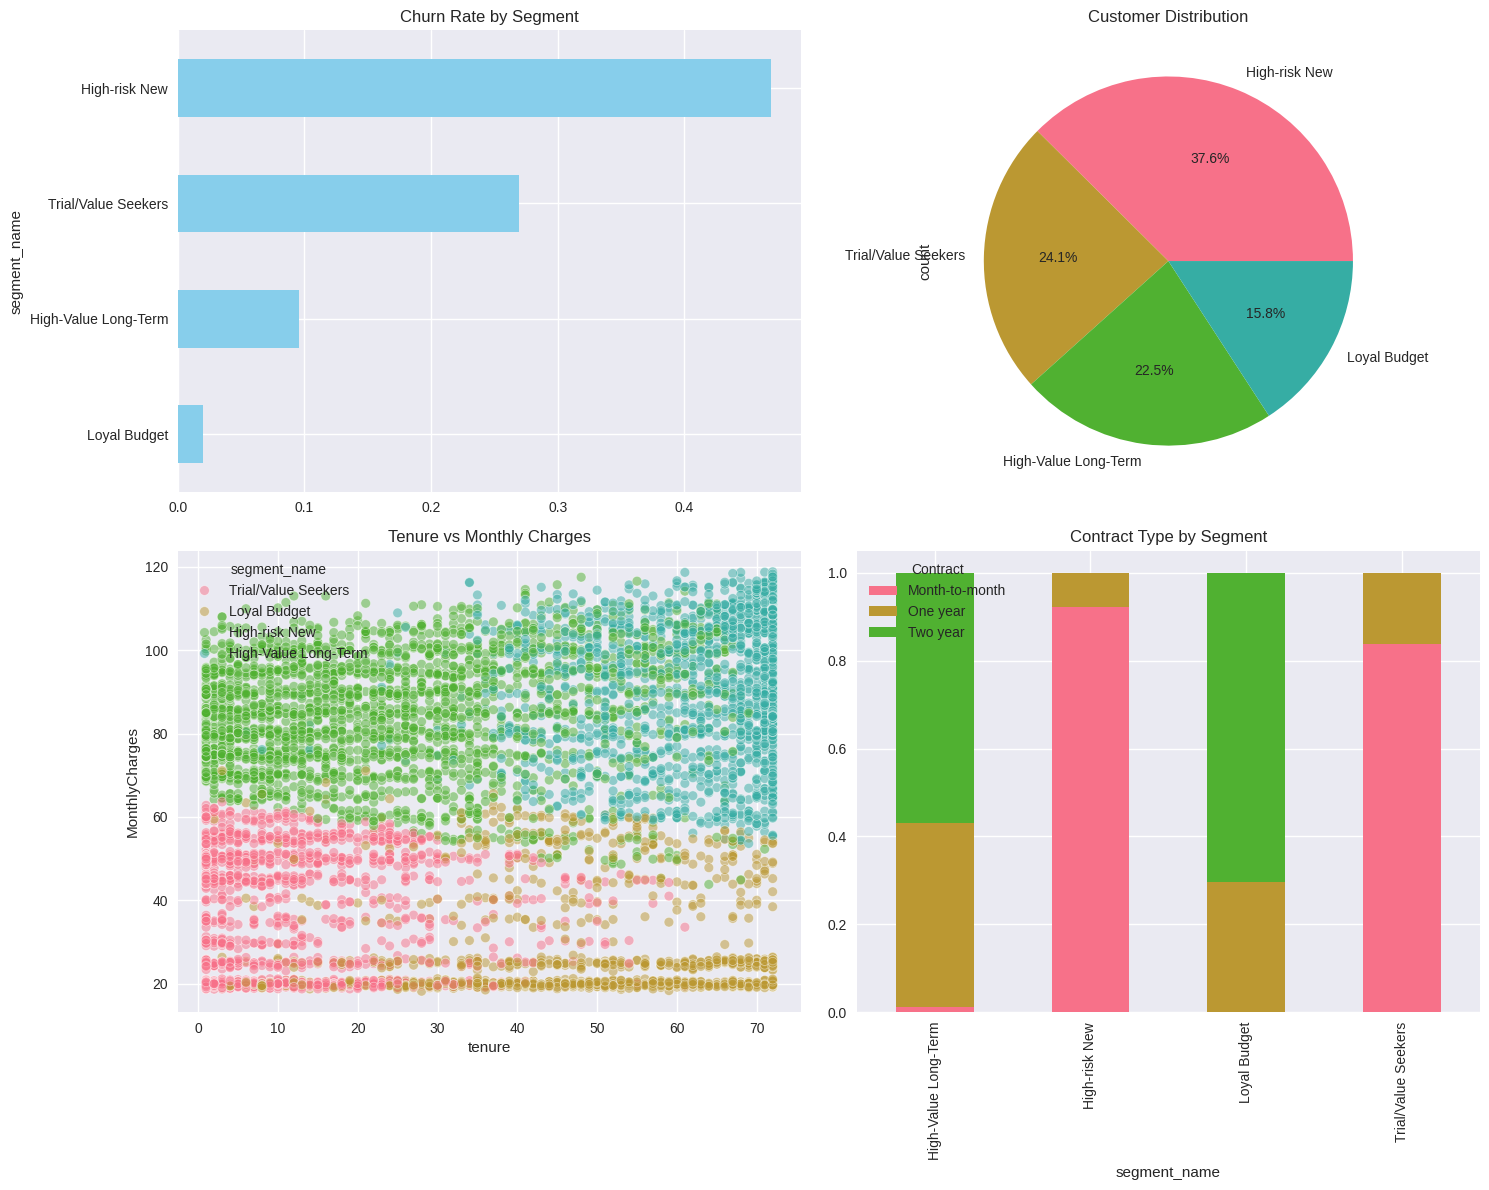

customer segmentation insights and recomondateion
Analysis date: 2026-03-15
Total customer analysis: 7032
Overall churn rate: 26.6%

 High risk segments(Above Avg churn):

 High-risk New
   .Churn rate:46.9% (vs avg26.6%)
   .Size:2641.0 customer
   .Avg Tenure:22.3 months
   .Avg Monthly Charge:83.61

 Low risk segments(Below Avg churn):

 High-Value Long-Term
   .Churn rate:9.6% (vs avg26.6%)
   .Size:1584.0 customer
   .Avg Tenure:61.1 months
   .Avg Monthly Charge:90.59

 Loyal Budget
   .Churn rate:2.0% (vs avg26.6%)
   .Size:1113.0 customer
   .Avg Tenure:47.9 months
   .Avg Monthly Charge:28.87

Key findings and recommendations

 Segment:High-Value Long-Term
  Profile:High spenders with long tenure
  Key metrics:
  .1584 customers(0.2% of base)
  .Churn rat:9.6% (rank #1 of 4)
  . Avg monthly revenue:$90.59
  .AVg customer lifetime:61.1 months

 Segment:High-risk New
  Profile:New customers, high spend, high risk
  Key metrics:
  .2641 customers(0.4% of base)
  .Churn rat:46.9% 

TypeError: can only concatenate str (not "int") to str

In [ ]:
#task 3
!pip install openpyxl --quiet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
print("libraries imported successfully")

#upload file
print("\n Telco_Customer_Churn_Dataset .csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#load data
if filename.endswith('.xlsx'):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename)
print(f"\n data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

#data exploration and preprocessing
#convert TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# handle missing values
df = df.dropna(subset=['TotalCharges'])

# select relevant columns
selected_columns = ['tenure', 'MonthlyCharges', 'Contract', 'Churn']
df_selected = df[selected_columns].copy()

#encode contract type
le_contract = LabelEncoder()
df_selected['Contract_encoded'] = le_contract.fit_transform(df_selected['Contract'])

#create binary churn column
df_selected['Churn_binary'] = (df_selected['Churn'] == 'Yes').astype(int)

print(f"overall churn rate: {df_selected['Churn_binary'].mean():.2%}")

#segmentation features and scaling
segmentation_features = ['tenure', 'MonthlyCharges', 'Contract_encoded']
x = df_selected[segmentation_features].copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#apply k-means
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_selected['segment'] = kmeans.fit_predict(x_scaled)

#name segments
overall_tenure_median = df_selected['tenure'].median()
overall_monthly_median = df_selected['MonthlyCharges'].median()

segment_names = {}
segment_descriptions = {}

for i in range(optimal_k):
    segment_data = df_selected[df_selected['segment'] == i]
    avg_tenure = segment_data['tenure'].mean()
    avg_monthly = segment_data['MonthlyCharges'].mean()
    primary_contract = segment_data['Contract'].mode()[0]
    churn_rate = segment_data['Churn_binary'].mean()

    if avg_tenure > overall_tenure_median and avg_monthly > overall_monthly_median:
        if 'Month-to-month' in primary_contract:
            segment_names[i] = 'High-Value Short-Term'
            segment_descriptions[i] = 'High spenders with short commitment'
        else:
            segment_names[i] = 'High-Value Long-Term'
            segment_descriptions[i] = 'High spenders with long tenure'
    elif avg_tenure > overall_tenure_median and avg_monthly <= overall_monthly_median:
        segment_names[i] = 'Loyal Budget'
        segment_descriptions[i] = 'Long-term, cost-conscious'
    elif avg_tenure <= overall_tenure_median and avg_monthly > overall_monthly_median:
        segment_names[i] = 'High-risk New'
        segment_descriptions[i] = 'New customers, high spend, high risk'
    else:
        segment_names[i] = 'Trial/Value Seekers'
        segment_descriptions[i] = 'Testing services or budget conscious'

df_selected['segment_name'] = df_selected['segment'].map(segment_names)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Churn Rate by Segment
churn_by_seg = df_selected.groupby('segment_name')['Churn_binary'].mean().sort_values()
churn_by_seg.plot(kind='barh', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Churn Rate by Segment')

# Segment Size
df_selected['segment_name'].value_counts().plot(kind='pie', ax=axes[0,1], autopct='%1.1f%%')
axes[0,1].set_title('Customer Distribution')

# Tenure vs Charges
sns.scatterplot(data=df_selected, x='tenure', y='MonthlyCharges', hue='segment_name', ax=axes[1,0], alpha=0.5)
axes[1,0].set_title('Tenure vs Monthly Charges')

# Contract Distribution
pd.crosstab(df_selected['segment_name'], df_selected['Contract'], normalize='index').plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Contract Type by Segment')

plt.tight_layout()
plt.show()

# Create churn_analysis DataFrame (moved here to define before use)
churn_analysis = df_selected.groupby('segment_name').agg(
    **{
        'Total Customer': ('segment_name', 'size'),
        'Churn Rate': ('Churn_binary', 'mean'),
        'Avg Tenure': ('tenure', 'mean'),
        'Avg Monthly Charge': ('MonthlyCharges', 'mean')
    }
).reset_index().set_index('segment_name')

# Calculate Total Revenue for each segment
churn_analysis['Total Revenue'] = churn_analysis['Total Customer'] * churn_analysis['Avg Monthly Charge']

#step12. genarate business insights and recommendations
print("="*80)
print("customer segmentation insights and recomondateion")
print("="*80)
print(f"Analysis date: {pd.Timestamp.now().strftime('%Y-%m-%d')}")
print(f"Total customer analysis: {len(df_selected)}")
print(f"Overall churn rate: {df_selected['Churn_binary'].mean():.1%}")
print("="*80)

# identify higy_risy segments
high_risk_segments=churn_analysis[churn_analysis['Churn Rate'] > df_selected['Churn_binary'].mean()].index.tolist()
low_risk_segments=churn_analysis[churn_analysis['Churn Rate'] <= df_selected['Churn_binary'].mean()].index.tolist()

print(f"\n High risk segments(Above Avg churn):")
for segment in high_risk_segments:
    data=churn_analysis.loc[segment]
    print(f"\n {segment}")
    # Corrected SyntaxError: included 'vs avg' in the f-string
    print(f"   .Churn rate:{data['Churn Rate']:.1%} (vs avg{df_selected['Churn_binary'].mean():.1%})")
    print(f"   .Size:{data['Total Customer']} customer")
    print(f"   .Avg Tenure:{data['Avg Tenure']:.1f} months")
    print(f"   .Avg Monthly Charge:{data['Avg Monthly Charge']:.2f}")


    print(f"\n Low risk segments(Below Avg churn):")
    for segment in low_risk_segments:
        data=churn_analysis.loc[segment]
        print(f"\n {segment}")
        # Corrected SyntaxError: included 'vs avg' in the f-string
        print(f"   .Churn rate:{data['Churn Rate']:.1%} (vs avg{df_selected['Churn_binary'].mean():.1%})")
        print(f"   .Size:{data['Total Customer']} customer")
        print(f"   .Avg Tenure:{data['Avg Tenure']:.1f} months")
        print(f"   .Avg Monthly Charge:{data['Avg Monthly Charge']:.2f}")

    print("\n "+"="*80)
    print("Key findings and recommendations")
    print("="*80)

    for segment in churn_analysis.index:
        data=churn_analysis.loc[segment]
        churn_rate=data['Churn Rate']
        avg_tenure=data['Avg Tenure']
        avg_charges= data['Avg Monthly Charge']

        print(f"\n Segment:{segment}")
        print(f"  Profile:{segment_descriptions[int(df_selected[df_selected['segment_name'] == segment]['segment'].iloc[0])]}")
        print(f"  Key metrics:")
        print(f"  .{int(data['Total Customer'])} customers({data['Total Customer']/len(df_selected):.1f}% of base)")
        print(f"  .Churn rat:{churn_rate:.1%} (rank #{churn_analysis.index.get_loc(segment) + 1} of {len(churn_analysis)})")
        print(f"  . Avg monthly revenue:${avg_charges:.2f}")
        print(f"  .AVg customer lifetime:{avg_tenure:.1f} months")

    #generate specific recommendations
    print(f"\n  Recomondation:")
    if churn_rate>0.3:
        print(" Critical- Immediate intervention required:")
        if 'New' in segment or 'Trial' in segment:
            print("  .Implement enhanced onbording program")
            print("  .Offer first-month discount for annual commitents")
            print("  .Send personalized welcome series with value propositions")
            print("  .Conduct exit surverys to identify pain points")
        elif 'High-risk' in segment:
            print("  .Launch win-back campaign with exclusive offers")
            print("  .Analyze support tickets and complaints")
            print("  . Consider price adjustment or bundle offers")
            print("  .Implement loyalty points program")
        else:
            print("  .Conduct in-depth customer interviews")
            print("  .Review service quality and responsiveness")
            print("  .Create targeted retention offers")



    elif churn_rate >0.15:
        print(" Moderate risk=proactive retention needed:")
        if avg_tenure<12:
            print("  .Offer contract renewal incentives before term ends")
            print("  .Send satisfaction surveys and act on feedback")
            print("  .Provide upgrade options with discounts")
        else:
            print("  .Recognize loyalty with anniversary rewards")
            print("  .Offer exclusive perks for long-term customers")
            print("  .Encourage referrals with double-sided incentives")
    else:
        print("Loe risk -Focus on growth and advocacy:")
        if'Premium' in segment or 'High-value' in segment: # Corrected 'degment' to 'segment'
            print("  .Enroll in VIP customer program")
            print("  .Invite to product beta testing")
            print("  .Feature in customer success stories")
            print("  .Offer premium support services")
        else:
            print("  .Leverage as brand ambassadors")
            print("  .Create referral bonus program")
            print("  .Upsell additional services")
            print("  .Request online reviews and testimonials")
print("\n"+"="*80)
print("Strategic priorities by segment")
print("="*80)

# create pririty matrix
priority_matrix=pd.DataFrame({
    'Segment': churn_analysis.index,
    'Size': churn_analysis['Total Customer'].values,
    'Churn Rate': churn_analysis['Churn Rate'].values,
    'Revenue Impact': churn_analysis['Total Revenue']*churn_analysis['Avg Monthly Charge']*12,
    'Priority Score':churn_analysis['Churn Rate']*churn_analysis['Total Customer']
}).sort_values('Priority Score', ascending=False)

priority_matrix['Priority Score']=priority_matrix['Priority Score'].round(0)
priority_matrix['Revenue Impact']=priority_matrix['Revenue Impact'].round(0)

print("\n Priority ranking (Higher score=higher priority for retention):")
for idx, row in priority_matrix.iterrows():
    print(f"\n {idx+1}.{row['Segment']}:")
    print(f"  .Priority Score:{int(row['Priority Score']):,}")
    print(f"  .Annual Revenue Impact:${int(row['Revenue Impact']):,}")
    print(f"  .customers:{int(row['Size']):,}")

print("\n"+"="*80)
print("summary")
print("="*80)
print(f" .Most valuable segment:{churn_analysis[churn_analysis['Avg Monthly Charge']==churn_analysis['Avg Monthly Charge'].max()].index[0]}")
print(f" .Most loyal segment:{churn_analysis[churn_analysis['Avg Tenure']==churn_analysis['Avg Tenure'].max()].index[0]}")
print(f" .Highest churn segment:{churn_analysis[churn_analysis['Churn Rate']==churn_analysis['Churn Rate'].max()].index[0]}")
print(f" .largest segment:{churn_analysis[churn_analysis['Total Customer']==churn_analysis['Total Customer'].max()].index[0]}")
print(f" .Potential revenue saved by reducing churn in high-risk segment by 10%: ${priority_matrix[priority_matrix['Churn Rate']>df_selected['Churn_binary'].mean()]['Revenue Impact'].sum()*0.1:,.0f}")

#sep 13.save results
#add segment information bavck to original dataframe
df['segment']=df_selected['segment']
df['segment_name']=df_selected['segment_name']
df['segment_description']=df_selected['segment'].map(segment_descriptions) # Corrected: use segment_descriptions dict

#save the enriched dataset
output_filename='telco_customer_segments.csv'
df.to_csv(output_filename, index=False)
print(f"enriched dataset saved as:{output_filename}")

#save analysis results
churn_analysis.to_csv('churn_analysis_by_segment.csv')
priority_matrix.to_csv('segment_priority_matrix.csv', index=False)

#create a summary report
with open('segmentation_summary_report.txt','w')as f:
    f.write("="*80+"\n")
    f.write("Telco customer segmentationsummary report\n")
    f.write("="*80+"\n")
    f.write(f"Analysis data:{pd.Timestamp.now().strftime('%Y-%m-%d')}\n")
    f.write(f"Total cusomer :{len(df_selected):,}\n")
    f.write(f"Overall churn rate:{df_selected['Churn_binary'].mean():.1%}\n \n")

    f.write("Segment profiles:\n")
    f.write("-"*50+"\n")
    for segment in churn_analysis.index:
        data=churn_analysis.loc[segment]
        f.write(f"\n{segment}:\n")
        f.write(f" Size: {int(data['Total Customer'])} ({data['Total Customer'] / len(df_selected) * 100:.1f}%)\n")
        f.write(f" Churn rate:{data['Churn Rate']:.1%}\n")
        f.write(f" Avg Tenure:{data['Avg Tenure']:.1f} \n")
        f.write(f" Avg Monthly Charges:${data['Avg Monthly Charge']:,.2f} \n")

        f.write("\n"+"="*80+"\n")
        f.write("Recommendation by priority:\n")
        f.write("="*80+"\n")
        for idx, row in priority_matrix.iterrows():
            f.write(f"\n{idx+1}.{row['Segment']}(Priority Score: {row['Priority Score']}):\n")
            f.write("Action: Focus on retention with targeted campaigns\n")
        print("\n Analysis files saved:")
        print("  .telco_customer_segments.csv")
        print("  .churn_analysis_by_segment.csv - Enriched data set with segment labels")